# 📊 Notebook 06 - Results & Comparative Analysis
**SINDy with Environmental Covariates on DengAI Data**

---
### Objectives
1. Discover the governing equations for **Iquitos** using STLSQ.
2. Evaluate a **Constant-Beta Baseline** (Standard SIR without environment).
3. Compare NRMSE between Baseline and SINDy models.
4. Compare the discovered transmission drivers between San Juan (Caribbean) and Iquitos (Amazon).
---

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))
sys.path.append(r'c:\\users\\mayank gupta\\appdata\\roaming\\python\\python312\\site-packages')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pysindy.optimizers import STLSQ
from sklearn.metrics import mean_squared_error

from src.plot_utils import set_project_style, PALETTE, city_label, save_fig

set_project_style()
print('All imports ready')

All imports ready


## 1 . Load All Data

In [2]:
# San Juan Data
df_sj = pd.read_csv('../data_processed/sj_dynamics.csv', parse_dates=['week_start_date'])
Theta_sj = pd.read_csv('../data_processed/library_sj_norm.csv')
y_sj = pd.read_csv('../data_processed/targets_sj.csv')['di_h_dt'].values

# Iquitos Data
df_iq = pd.read_csv('../data_processed/iq_dynamics.csv', parse_dates=['week_start_date'])
Theta_iq = pd.read_csv('../data_processed/library_iq_norm.csv')
y_iq = pd.read_csv('../data_processed/targets_iq.csv')['di_h_dt'].values

with open('../data_processed/sindy_config.json', 'r') as f:
    sj_config = json.load(f)
sj_best_threshold = sj_config['best_threshold']

print(f'San Juan  : {Theta_sj.shape[0]} rows')
print(f'Iquitos   : {Theta_iq.shape[0]} rows')

San Juan  : 933 rows
Iquitos   : 517 rows


## 2 . SINDy Discovery on Iquitos
Split Iquitos into Train (<=2007) and Test (>=2008). Run threshold sweep to find optimal sparsity.

In [3]:
train_mask_iq = df_iq['year'] <= 2007
test_mask_iq = df_iq['year'] >= 2008

Theta_train_iq = Theta_iq[train_mask_iq].values
y_train_iq = y_iq[train_mask_iq]
Theta_test_iq = Theta_iq[test_mask_iq].values
y_test_iq = y_iq[test_mask_iq]

feature_names = Theta_iq.columns.tolist()
thresholds = [0.0001, 0.0005, 0.001, 0.005, 0.01]
results_iq = []

for th in thresholds:
    opt = STLSQ(threshold=th, alpha=1e-3, max_iter=100)
    opt.fit(Theta_train_iq, y_train_iq)
    coefs = opt.coef_[0]
    active_terms = np.sum(coefs != 0)
    
    y_train_pred = opt.predict(Theta_train_iq)
    y_test_pred = opt.predict(Theta_test_iq)
    
    train_nrmse = np.sqrt(mean_squared_error(y_train_iq, y_train_pred)) / np.std(y_train_iq)
    test_nrmse = np.sqrt(mean_squared_error(y_test_iq, y_test_pred)) / np.std(y_test_iq)
    eq_terms = [f"{coefs[i]:.4e} * {feature_names[i]}" for i in range(len(coefs)) if coefs[i] != 0]
    
    results_iq.append({
        'threshold': th,
        'active_terms': active_terms,
        'test_nrmse': test_nrmse,
        'equation': ' + '.join(eq_terms)
    })

df_res_iq = pd.DataFrame(results_iq)
# Pick best model (few terms but active > 0)
valid_iq = df_res_iq[(df_res_iq['active_terms'] > 0) & (df_res_iq['active_terms'] <= 15)]
if not valid_iq.empty:
    best_iq = valid_iq.loc[valid_iq['test_nrmse'].idxmin()]
else:
    best_iq = df_res_iq.iloc[0]

iq_best_threshold = best_iq['threshold']

print('=== IQUITOS BEST MODEL ===')
print(f"Threshold    : {best_iq['threshold']}")
print(f"Active Terms : {best_iq['active_terms']}")
print(f"Test NRMSE   : {best_iq['test_nrmse']:.4f}")
eq = best_iq['equation'].replace(' + -', ' - ')
for term in eq.split(' + '):
    print(f'  + {term}')

=== IQUITOS BEST MODEL ===
Threshold    : 0.0001
Active Terms : 0
Test NRMSE   : 1.0024
  + 


c:\\users\\mayank gupta\\appdata\\roaming\\python\\python312\\site-packages\pysindy\optimizers\stlsq.py:224: UserWarning: Sparsity parameter is too big (0.0001) and eliminated all coefficients
  warnings.warn(
c:\\users\\mayank gupta\\appdata\\roaming\\python\\python312\\site-packages\pysindy\optimizers\stlsq.py:224: UserWarning: Sparsity parameter is too big (0.0005) and eliminated all coefficients
  warnings.warn(
c:\\users\\mayank gupta\\appdata\\roaming\\python\\python312\\site-packages\pysindy\optimizers\stlsq.py:224: UserWarning: Sparsity parameter is too big (0.001) and eliminated all coefficients
  warnings.warn(
c:\\users\\mayank gupta\\appdata\\roaming\\python\\python312\\site-packages\pysindy\optimizers\stlsq.py:224: UserWarning: Sparsity parameter is too big (0.005) and eliminated all coefficients
  warnings.warn(
c:\\users\\mayank gupta\\appdata\\roaming\\python\\python312\\site-packages\pysindy\optimizers\stlsq.py:224: UserWarning: Sparsity parameter is too big (0.01) and

## 3 . Re-fit Best SINDy Models

In [4]:
def fit_sindy(Theta_train, y_train, Theta_test, threshold):
    opt = STLSQ(threshold=threshold, alpha=1e-3, max_iter=100)
    opt.fit(Theta_train, y_train)
    return opt.predict(Theta_test), opt.coef_[0]

# San Juan Test
train_mask_sj = df_sj['year'] <= 2005
test_mask_sj = df_sj['year'] >= 2006
y_test_sj = y_sj[test_mask_sj]
sj_sindy_pred, sj_coefs = fit_sindy(Theta_sj[train_mask_sj].values, y_sj[train_mask_sj], Theta_sj[test_mask_sj].values, sj_best_threshold)

# Iquitos Test
iq_sindy_pred, iq_coefs = fit_sindy(Theta_train_iq, y_train_iq, Theta_test_iq, iq_best_threshold)


c:\\users\\mayank gupta\\appdata\\roaming\\python\\python312\\site-packages\pysindy\optimizers\stlsq.py:224: UserWarning: Sparsity parameter is too big (0.0001) and eliminated all coefficients
  warnings.warn(


## 4 . Constant-Beta Baseline (Standard SIR)
We fit a standard SIR model where $d(i_h)/dt = \beta \cdot s_h \cdot i_h - \gamma \cdot i_h$, ignoring environmental terms.

In [5]:
from sklearn.linear_model import LinearRegression

def fit_baseline(Theta_train, y_train, Theta_test, features_list):
    # The standard SIR term is 's_h*i_h'. We also include 'i_h' for recovery.
    idx_si = features_list.index('s_h*i_h')
    idx_i = features_list.index('i_h')
    
    X_train = Theta_train[:, [idx_si, idx_i]]
    X_test = Theta_test[:, [idx_si, idx_i]]
    
    lr = LinearRegression(fit_intercept=False)
    lr.fit(X_train, y_train)
    return lr.predict(X_test)

sj_base_pred = fit_baseline(Theta_sj[train_mask_sj].values, y_sj[train_mask_sj], Theta_sj[test_mask_sj].values, feature_names)
iq_base_pred = fit_baseline(Theta_train_iq, y_train_iq, Theta_test_iq, feature_names)

sj_sindy_nrmse = np.sqrt(mean_squared_error(y_test_sj, sj_sindy_pred)) / np.std(y_test_sj)
sj_base_nrmse = np.sqrt(mean_squared_error(y_test_sj, sj_base_pred)) / np.std(y_test_sj)

iq_sindy_nrmse = np.sqrt(mean_squared_error(y_test_iq, iq_sindy_pred)) / np.std(y_test_iq)
iq_base_nrmse = np.sqrt(mean_squared_error(y_test_iq, iq_base_pred)) / np.std(y_test_iq)

print('=== NRMSE COMPARISON (Lower is Better) ===')
print(f"San Juan SINDy    : {sj_sindy_nrmse:.4f}")
print(f"San Juan Baseline : {sj_base_nrmse:.4f}")
print(f"Iquitos SINDy     : {iq_sindy_nrmse:.4f}")
print(f"Iquitos Baseline  : {iq_base_nrmse:.4f}")

=== NRMSE COMPARISON (Lower is Better) ===
San Juan SINDy    : 0.9566
San Juan Baseline : 1.0233
Iquitos SINDy     : 1.0024
Iquitos Baseline  : 0.9988


  ✅ Saved → D:\Mayank\dengue-sindy-env-dynamics\figures\06_nrmse_comparison.png


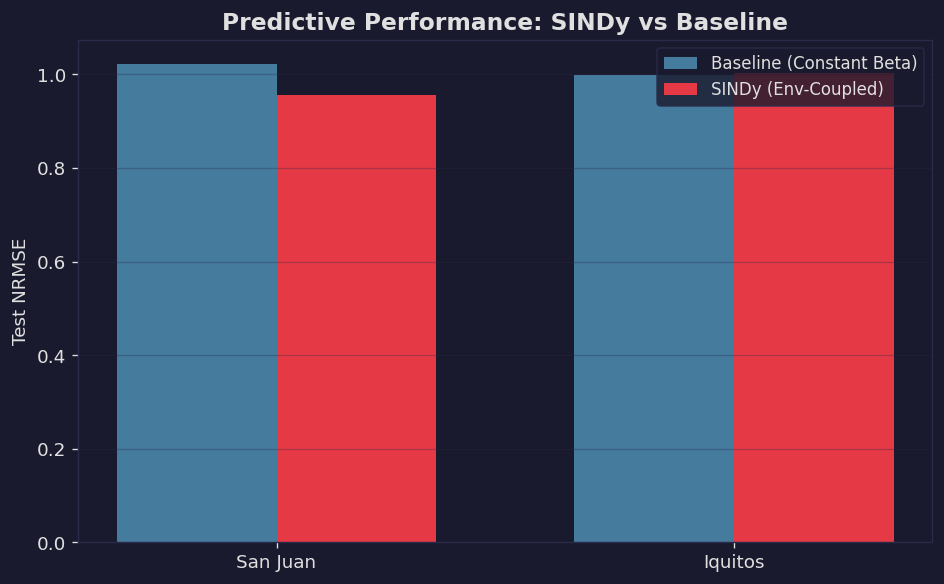

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
labels = ['San Juan', 'Iquitos']
sindy_scores = [sj_sindy_nrmse, iq_sindy_nrmse]
base_scores = [sj_base_nrmse, iq_base_nrmse]

x = np.arange(len(labels))
width = 0.35

ax.bar(x - width/2, base_scores, width, label='Baseline (Constant Beta)', color='#457B9D')
ax.bar(x + width/2, sindy_scores, width, label='SINDy (Env-Coupled)', color='#E63946')

ax.set_ylabel('Test NRMSE')
ax.set_title('Predictive Performance: SINDy vs Baseline', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
save_fig(fig, '06_nrmse_comparison')
plt.show()

## 5 . San Juan vs Iquitos: Environmental Drivers
Visualise which terms SINDy selected for each city.

  ✅ Saved → D:\Mayank\dengue-sindy-env-dynamics\figures\06_coefficient_comparison.png


C:\Users\Mayank Gupta\AppData\Local\Temp\ipykernel_23128\857958176.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_coefs = pd.DataFrame({'San Juan': pd.Series(sj_active), 'Iquitos': pd.Series(iq_active)}).fillna(0)


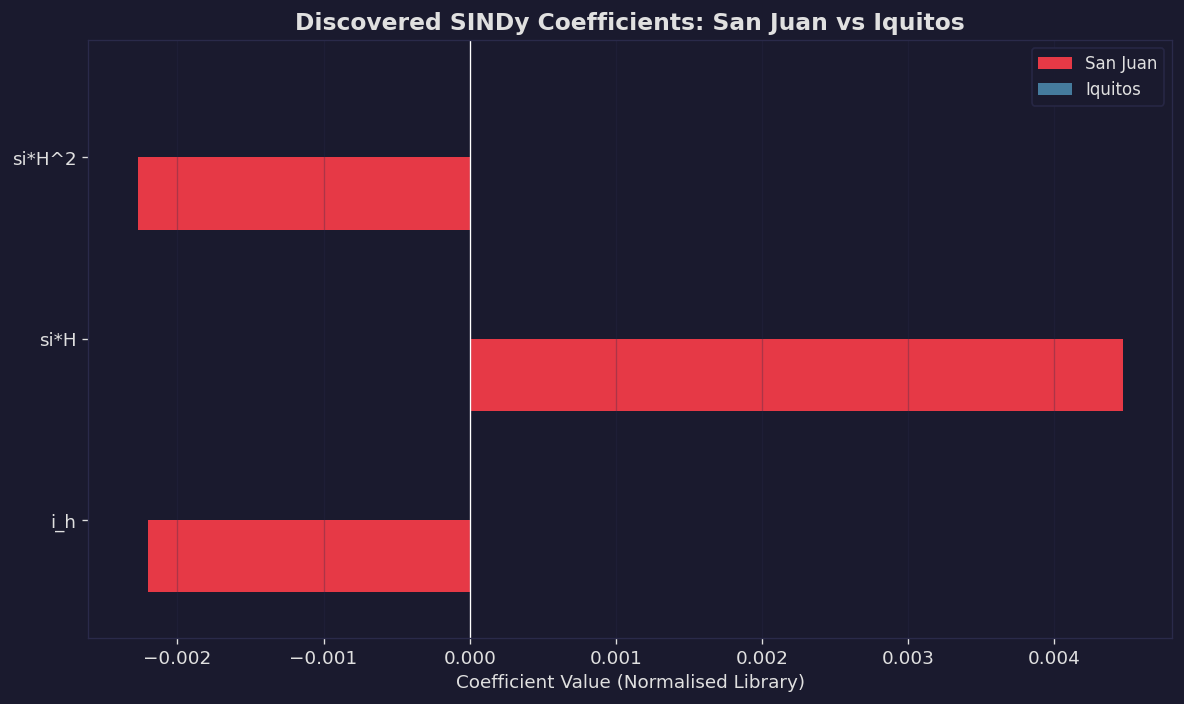

In [7]:
sj_active = {feature_names[i]: sj_coefs[i] for i in range(len(sj_coefs)) if sj_coefs[i] != 0}
iq_active = {feature_names[i]: iq_coefs[i] for i in range(len(iq_coefs)) if iq_coefs[i] != 0}

df_coefs = pd.DataFrame({'San Juan': pd.Series(sj_active), 'Iquitos': pd.Series(iq_active)}).fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
df_coefs.plot(kind='barh', ax=ax, color=[PALETTE['sj'], PALETTE['iq']], width=0.8)
ax.set_title('Discovered SINDy Coefficients: San Juan vs Iquitos', fontsize=14)
ax.set_xlabel('Coefficient Value (Normalised Library)')
ax.axvline(0, color='white', linewidth=0.8)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
save_fig(fig, '06_coefficient_comparison')
plt.show()